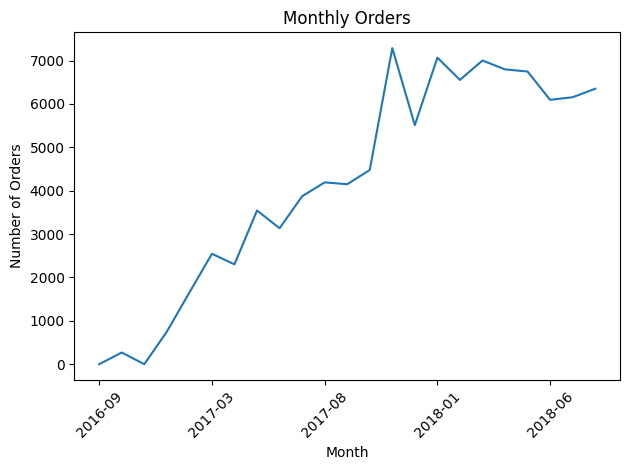

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/processed/orders_clean.csv")

monthly = orders.groupby("order_month").size()

monthly.plot(kind="line")
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../dashboard/monthly_orders.png")
plt.show()

## Q1: ¿Cuál es el volumen total de transacciones por mes? ¿Hay estacionalidad?

El volumen de transacciones muestra una clara tendencia creciente a lo largo del tiempo, especialmente desde inicios de 2017 hasta finales de ese mismo año.

### Insights:
- En los primeros meses se observa actividad baja, esto se puede deber a que no hay cobertura completa de los datos al inicio del dataset.
- Se observa un crecimiento sostenido en la cantidad de órdenes, lo que sugiere expansión del negocio o mayor adopción de la plataforma.
- Existe un pico notable hacia finales de 2017, lo cual puede estar relacionado con eventos estacionales como promociones de fin de año o Black Friday.
- Después del pico, el volumen se mantiene relativamente alto pero más estable, indicando una posible consolidación del crecimiento.
- No se observa una estacionalidad perfectamente cíclica (como patrones repetitivos cada año), pero sí evidencia de picos asociados a eventos específicos.

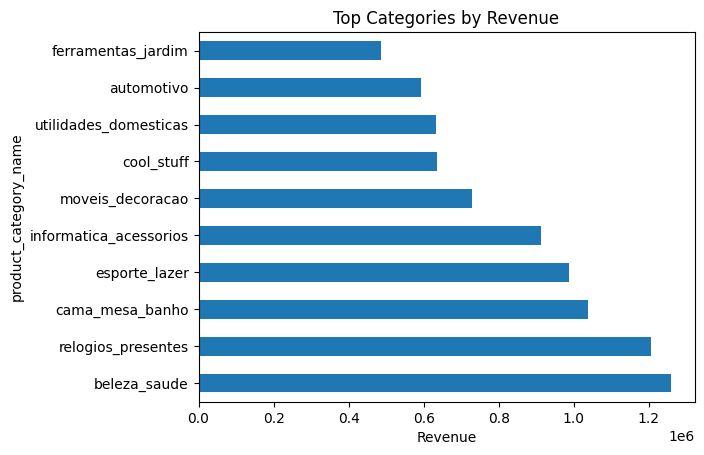

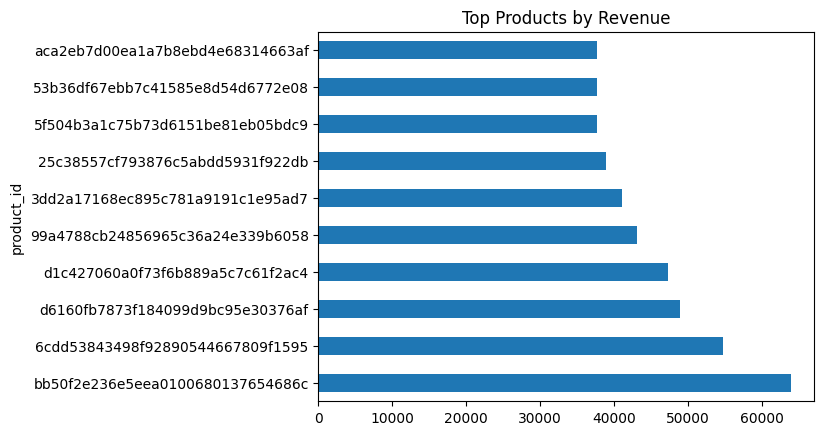

In [7]:
items = pd.read_csv("../data/processed/items_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")

df = items.merge(products, on="product_id")

top_categories = df.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind="barh")
plt.title("Top Categories by Revenue")
plt.xlabel("Revenue")

plt.savefig("../dashboard/top_categories.png")
plt.show()

top_products = df.groupby("product_id")["price"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh")
plt.title("Top Products by Revenue")
plt.savefig("../dashboard/top_products.png")
plt.show()

- A nivel de producto, también se observa concentración en un grupo reducido de items específicos.

## Q2: ¿Cuáles son los 10 clientes, productos o categorías con mayor valor generado?

Para este análisis, se evaluaron las categorías de productos como principal indicador de generación de valor, utilizando el ingreso total asociado a cada categoría.

### Insights:
- Las categorías **beleza_saude**, **relogios_presentes** y **cama_mesa_banho** son las principales generadoras de ingresos.
- Existe una alta concentración del valor en pocas categorías, lo que sugiere que una parte importante del negocio depende de segmentos específicos.
- Categorías como **informatica_acessorios** y **esporte_lazer** también tienen una participación relevante, aunque menor.

### Nota:
El análisis se centró en categorías por su capacidad de resumir el comportamiento del negocio. Sin embargo, este enfoque puede extenderse a nivel de productos o clientes para obtener una visión más granular.

### Implicaciones de negocio:
- Focalizar estrategias en categorías de alto rendimiento puede maximizar ingresos.
- Existe oportunidad de crecimiento en categorías con menor participación.

Average delivery time: 12.09 days


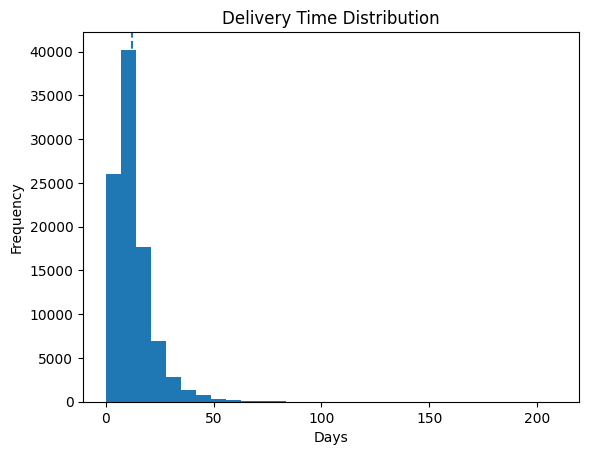

In [9]:
avg_delivery = orders["delivery_time_days"].mean()
print(f"Average delivery time: {avg_delivery:.2f} days")

orders["delivery_time_days"].dropna().plot(kind="hist", bins=30)

plt.axvline(avg_delivery, linestyle='--')
plt.title("Delivery Time Distribution")
plt.xlabel("Days")

plt.savefig("../dashboard/delivery_time.png")
plt.show()

## Q3: ¿Cuál es el tiempo promedio entre compra y entrega?

El tiempo promedio de entrega es aproximadamente **12 días**.

### Insights:
- La mayoría de las entregas se concentran en un rango relativamente bajo de días, como se observa en la distribución.
- Sin embargo, existe una cola larga hacia la derecha, lo que indica la presencia de entregas significativamente más tardías.
- Esto sugiere que, aunque el sistema logístico funciona eficientemente en general, hay casos atípicos que afectan el promedio.

### Implicaciones:
- Reducir estos casos extremos podría mejorar la experiencia del cliente sin necesidad de optimizar todo el sistema.

Negative outcome percentage: 12.73%


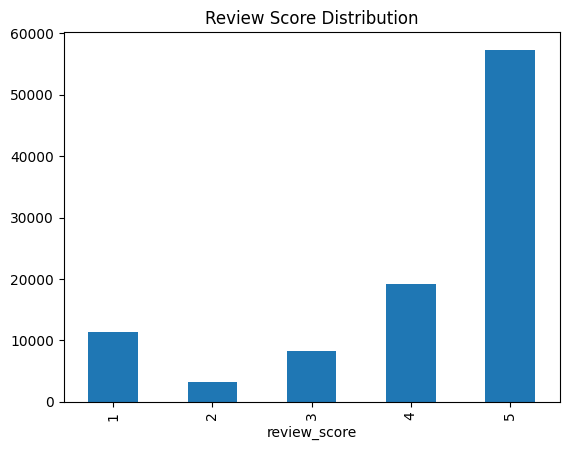

In [11]:
orders = pd.read_csv("../data/processed/orders_clean.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")

df = orders.merge(reviews, on="order_id", how="left")

# Negative condition
df["is_negative"] = (
    (df["order_status"] == "canceled") |
    (df["review_score"] <= 2)
)

negative_percentage = df["is_negative"].mean() * 100

print(f"Negative outcome percentage: {negative_percentage:.2f}%")

reviews = pd.read_csv("../data/processed/reviews_clean.csv")

reviews["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Review Score Distribution")

plt.savefig("../dashboard/reviews.png")
plt.show()

## Q4: ¿Qué porcentaje de registros tiene algún tipo de incidencia o resultado negativo?

Se definió como resultado negativo:
- órdenes canceladas, o
- órdenes con calificación ≤ 2

El porcentaje de registros con incidencias es aproximadamente **12.73%**.

### Insights:
- La mayoría de las órdenes tienen calificaciones altas (4 y 5), lo que indica una experiencia generalmente positiva.
- Sin embargo, existe un porcentaje no despreciable de resultados negativos, ya sea por cancelaciones o malas calificaciones.
- Aunque los casos negativos son minoritarios, pueden tener un impacto significativo en la percepción del servicio.

### Implicaciones:
- Reducir cancelaciones y mejorar la experiencia en entregas podría disminuir los resultados negativos.
- Las bajas calificaciones pueden estar relacionadas con problemas operativos como retrasos en la entrega.

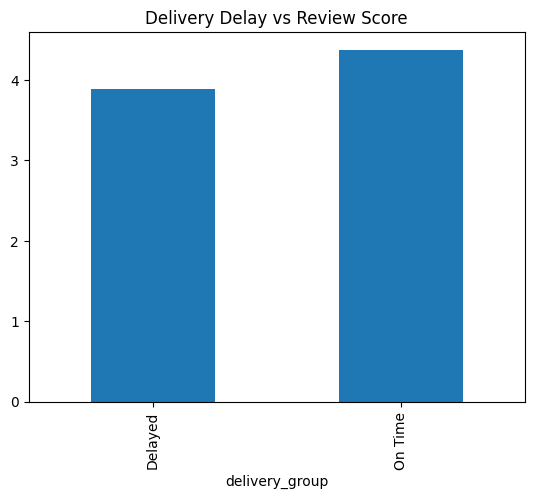

In [12]:
df = orders.merge(reviews, on="order_id")

df["delivery_group"] = df["delivery_time_days"].apply(
    lambda x: "Delayed" if x > 10 else "On Time"
)

result = df.groupby("delivery_group")["review_score"].mean()

result.plot(kind="bar")

plt.title("Delivery Delay vs Review Score")

plt.savefig("../dashboard/delivery_vs_review.png")
plt.show()

## Q5: ¿Existe una relación entre retrasos en la entrega y la satisfacción del cliente?

Se analiza si los pedidos con retrasos en la entrega presentan menores calificaciones por parte de los clientes.

### Insights:

- Los pedidos con retraso ("Delayed") presentan un promedio de calificación menor en comparación con los pedidos entregados a tiempo ("On Time").
- Esto indica una relación entre el desempeño logístico y la satisfacción del cliente.
- Incluso una diferencia relativamente pequeña en el tiempo de entrega puede tener un impacto negativo en la percepción del servicio.

### Interpretación:

- La puntualidad en las entregas es un factor crítico para la experiencia del cliente.
- Los retrasos no solo afectan la operación, sino también la reputación y la fidelización del cliente.

### Implicaciones de negocio:

- Optimizar los tiempos de entrega puede generar mejoras directas en la satisfacción del cliente.
- Reducir retrasos podría disminuir el número de calificaciones negativas y mejorar la percepción general de la plataforma.